# Vlasov-Poisson Mirror Model for Plasma Confinement (multi-species regime)

## Optimal confinement example

We study attempt to find an optimal configuration of the magnetic field $\mathbf{B}$ to maximize plasma confinement. 

### Installation

In [ ]:
# This might install JAX cpu version if you haven't installed a GPU version
# If you want to use JAX on the GPU check installation on README file.

!pip install git+https://github.com/maguerrap/vp-mirror_model.git@main

### Imports

In [1]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
Array = jax.Array
import jax.numpy as jnp

import optax
import equinox as eqx
from tqdm import tqdm

from vp_solver.jax_mirror_solver_full import make_mesh_full, VlasovPoissonSolverFull
from vp_solver.utils_mirror import BFieldMLP, load_b_trained, step_multi
from vp_solver.utils_mirror import get_initial_distribution_multi

# Plotting imports
from vp_solver.utils_plots import plot_magnetic_fields, plot_initial_distribution_multi
from vp_solver.utils_plots import normalize_final_multi, plot_final_distribution_multi, plot_energies_multi
from vp_solver.utils_plots import plot_rhos_multi, plot_int_rho_multi, plot_summray_opt_multi

### Problem and solver setup

Our goal is to find the optimal $\mathbf{B}$ which is parametrized through a multi-layer perceptron (MLP) such that $|\mathbf{B}(z)|:= \mathcal{N}(z;\theta)$. This becomes a PDE-constrained optimization problem defined as

$$
\max_{\theta} \, \mathcal{J}(\theta)
$$

subject to the following Vlasov-Poisson system

$$ \partial_t f_s
+
v\partial_z f_s
+
\left(
\frac{q_s}{m_s}E(t,z)
-
\mu \partial_z |\mathbf{B}(z)|
\right)\partial_v f_s
=
0,
$$

where
- $f_s(t,z,v,\mu)$ is the particle distribution for $s=e$ (electrons) and $s=i$ (ions).
- $q_s$ is the particle $s$ charge,
- $m_s$ is the particle $s$ mass,
- $\mathbf{B}(z)$ is the magnetic field,
- $E(t,z)$ is the electric field,
- $z \in [-L_z,L_z]$, $v \in \mathbb{R}$, $\mu\in\mathbb{R}_{+}$ and $t\in \mathbb{R}_{+}$.

The electric field is defined as $E(t,z) = -\partial_z \phi(t,z)$ where $\phi$ represents the electric potential and is obtained by solving the following Poisson equation:

$$\left\{\begin{array}{rcl}
-\partial_{zz}\phi
+
\partial_z\phi
\frac{\partial_z |\mathbf{B}(z)|}{|\mathbf{B}(z)|}
& = &
2\pi |\mathbf{B}(z)|
\iint
\left(
f_i - f_e
\right)
\,\mathrm{d}v\,\mathrm{d}\mu, \\
\phi(t,-L_z)
=
\phi(t,L_z)
&=&
0.
\end{array}
\right.
$$

We solve using a conservative semi-Lagrangian scheme with Strang operator splitting for time advancement.

We chose our objective functional $\mathcal{J}$ as follows

$$\mathcal{J}(\theta) = \sum_{s\in\{e,i\}}\int_{-L_z}^{L_z}\rho^{1D}_{s}(t,z;,\theta)\,\mathrm{d}z$$

where

$$
\rho_s^{1D}(t,z)
=
\iint
f_s(t,z,v,\mu)
\,\mathrm{d}v\,\mathrm{d}\mu\,.
$$

for species $s$.


In [2]:
# Setup for the forward solver
nz = 128
nv = 128
nmu = 128
dt = 0.1
t_final = 80.0
t_values = jnp.linspace(0, t_final, int(t_final / dt)+1)
LZ = 2 * jnp.pi
LV = 4.0
LMU = 2.8 # Given that B_max = 10.0

m_i = 25.0 # Ion mass relative to electron mass

# Note: Ion velocity domain is scaled by sqrt(1/m_i)
mesh = make_mesh_full(
    length_z=LZ, 
    length_v_e=LV, 
    length_v_i=LV / jnp.sqrt(m_i), 
    length_mu=LMU, 
    nz=nz, nv=nv, nmu=nmu
)

## B parameters
B_max = 10.0
B_min = 1.0

mirror_ratio = B_max/B_min
prop_trapped = jnp.sqrt((mirror_ratio - 1)/mirror_ratio)
print("Particles trapped: {:.3f}".format(prop_trapped))

Particles trapped: 0.949


#### Loading initial magnetic profile $|\mathbf{B}|$ and solver

In [3]:
seed = 0
key = jax.random.PRNGKey(seed)
b_model = BFieldMLP(key, center=0.0)

B_fn_grid_init, dB_fn_grid_init, B_eval_init, dB_eval_init, g_eval_init = load_b_trained(seed, mesh.zs)

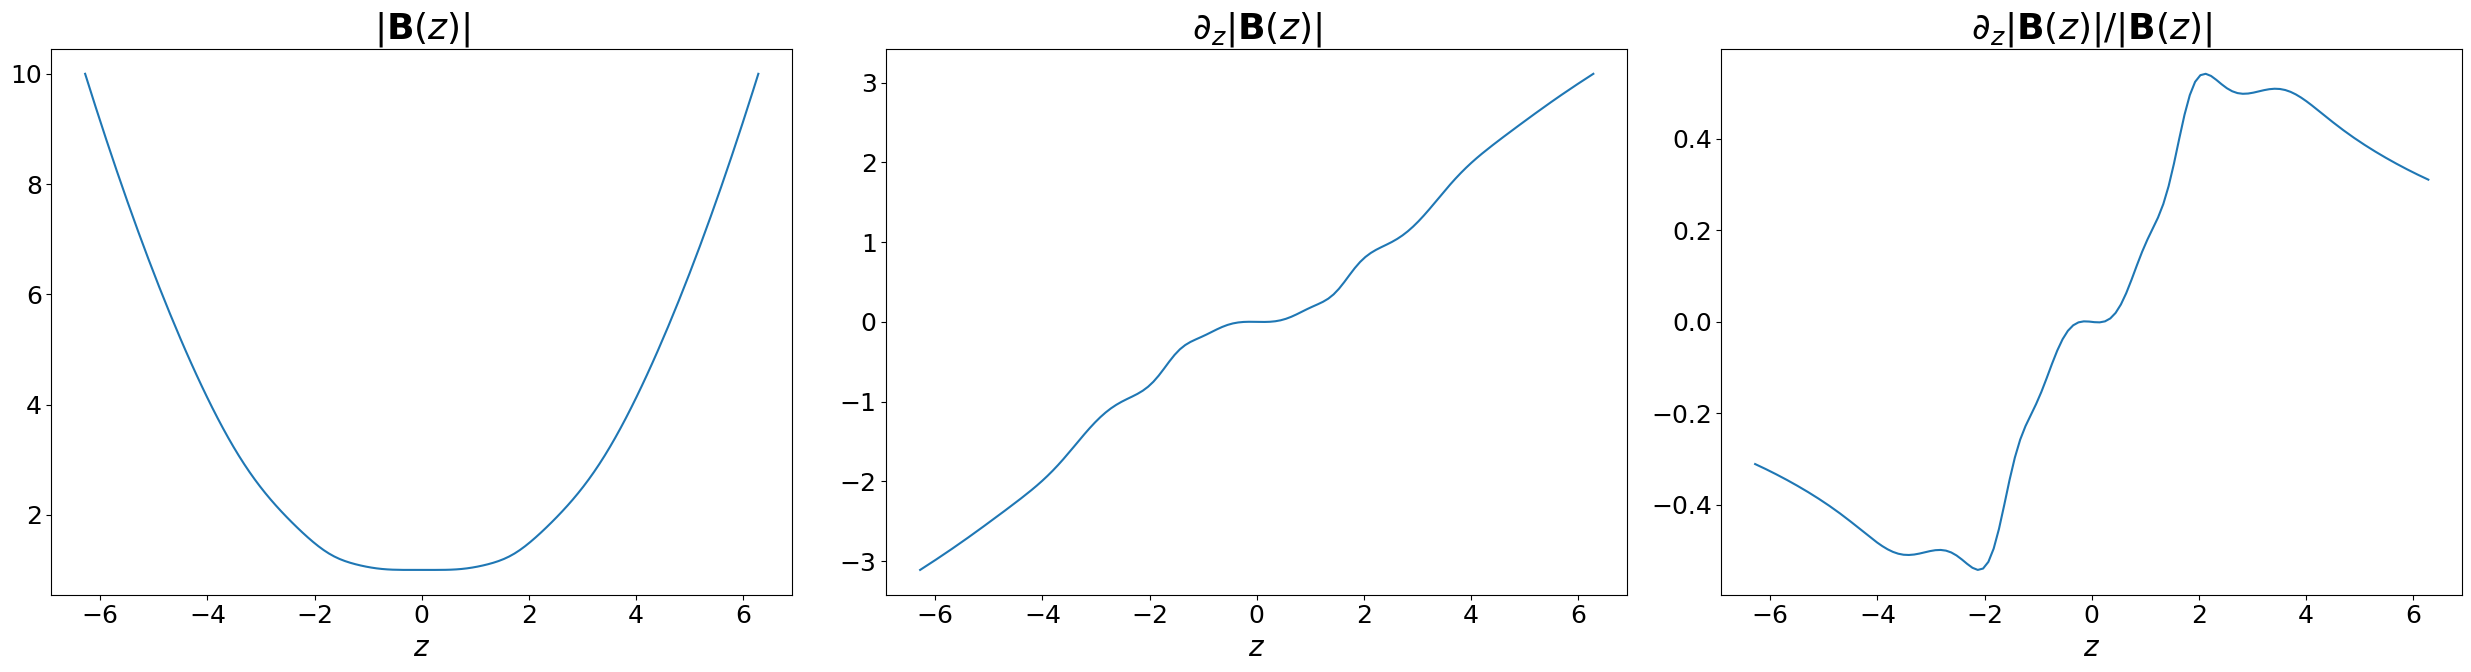

In [4]:
plot_magnetic_fields(B_eval_init, dB_eval_init, g_eval_init, mesh.zs)

We load and plot the initials $f_e$ and $f_i$ given our inital magnetic profile guess to compare later.

In [5]:
sigma_z = 0.8

f_iv_e_init, f_iv_i_init = get_initial_distribution_multi(B_fn_grid_init, sigma_z, mesh, m_i)

print("\\int\\rho_e dz: ", jnp.trapezoid(jnp.trapezoid(jnp.trapezoid(f_iv_e_init, x=mesh.mus, axis=2), x=mesh.vs_e, axis=1), x=mesh.zs, axis=0))
print("\\int\\rho_i dz: ", jnp.trapezoid(jnp.trapezoid(jnp.trapezoid(f_iv_i_init, x=mesh.mus, axis=2), x=mesh.vs_i, axis=1), x=mesh.zs, axis=0))

\int\rho_e dz:  1.0
\int\rho_i dz:  1.0


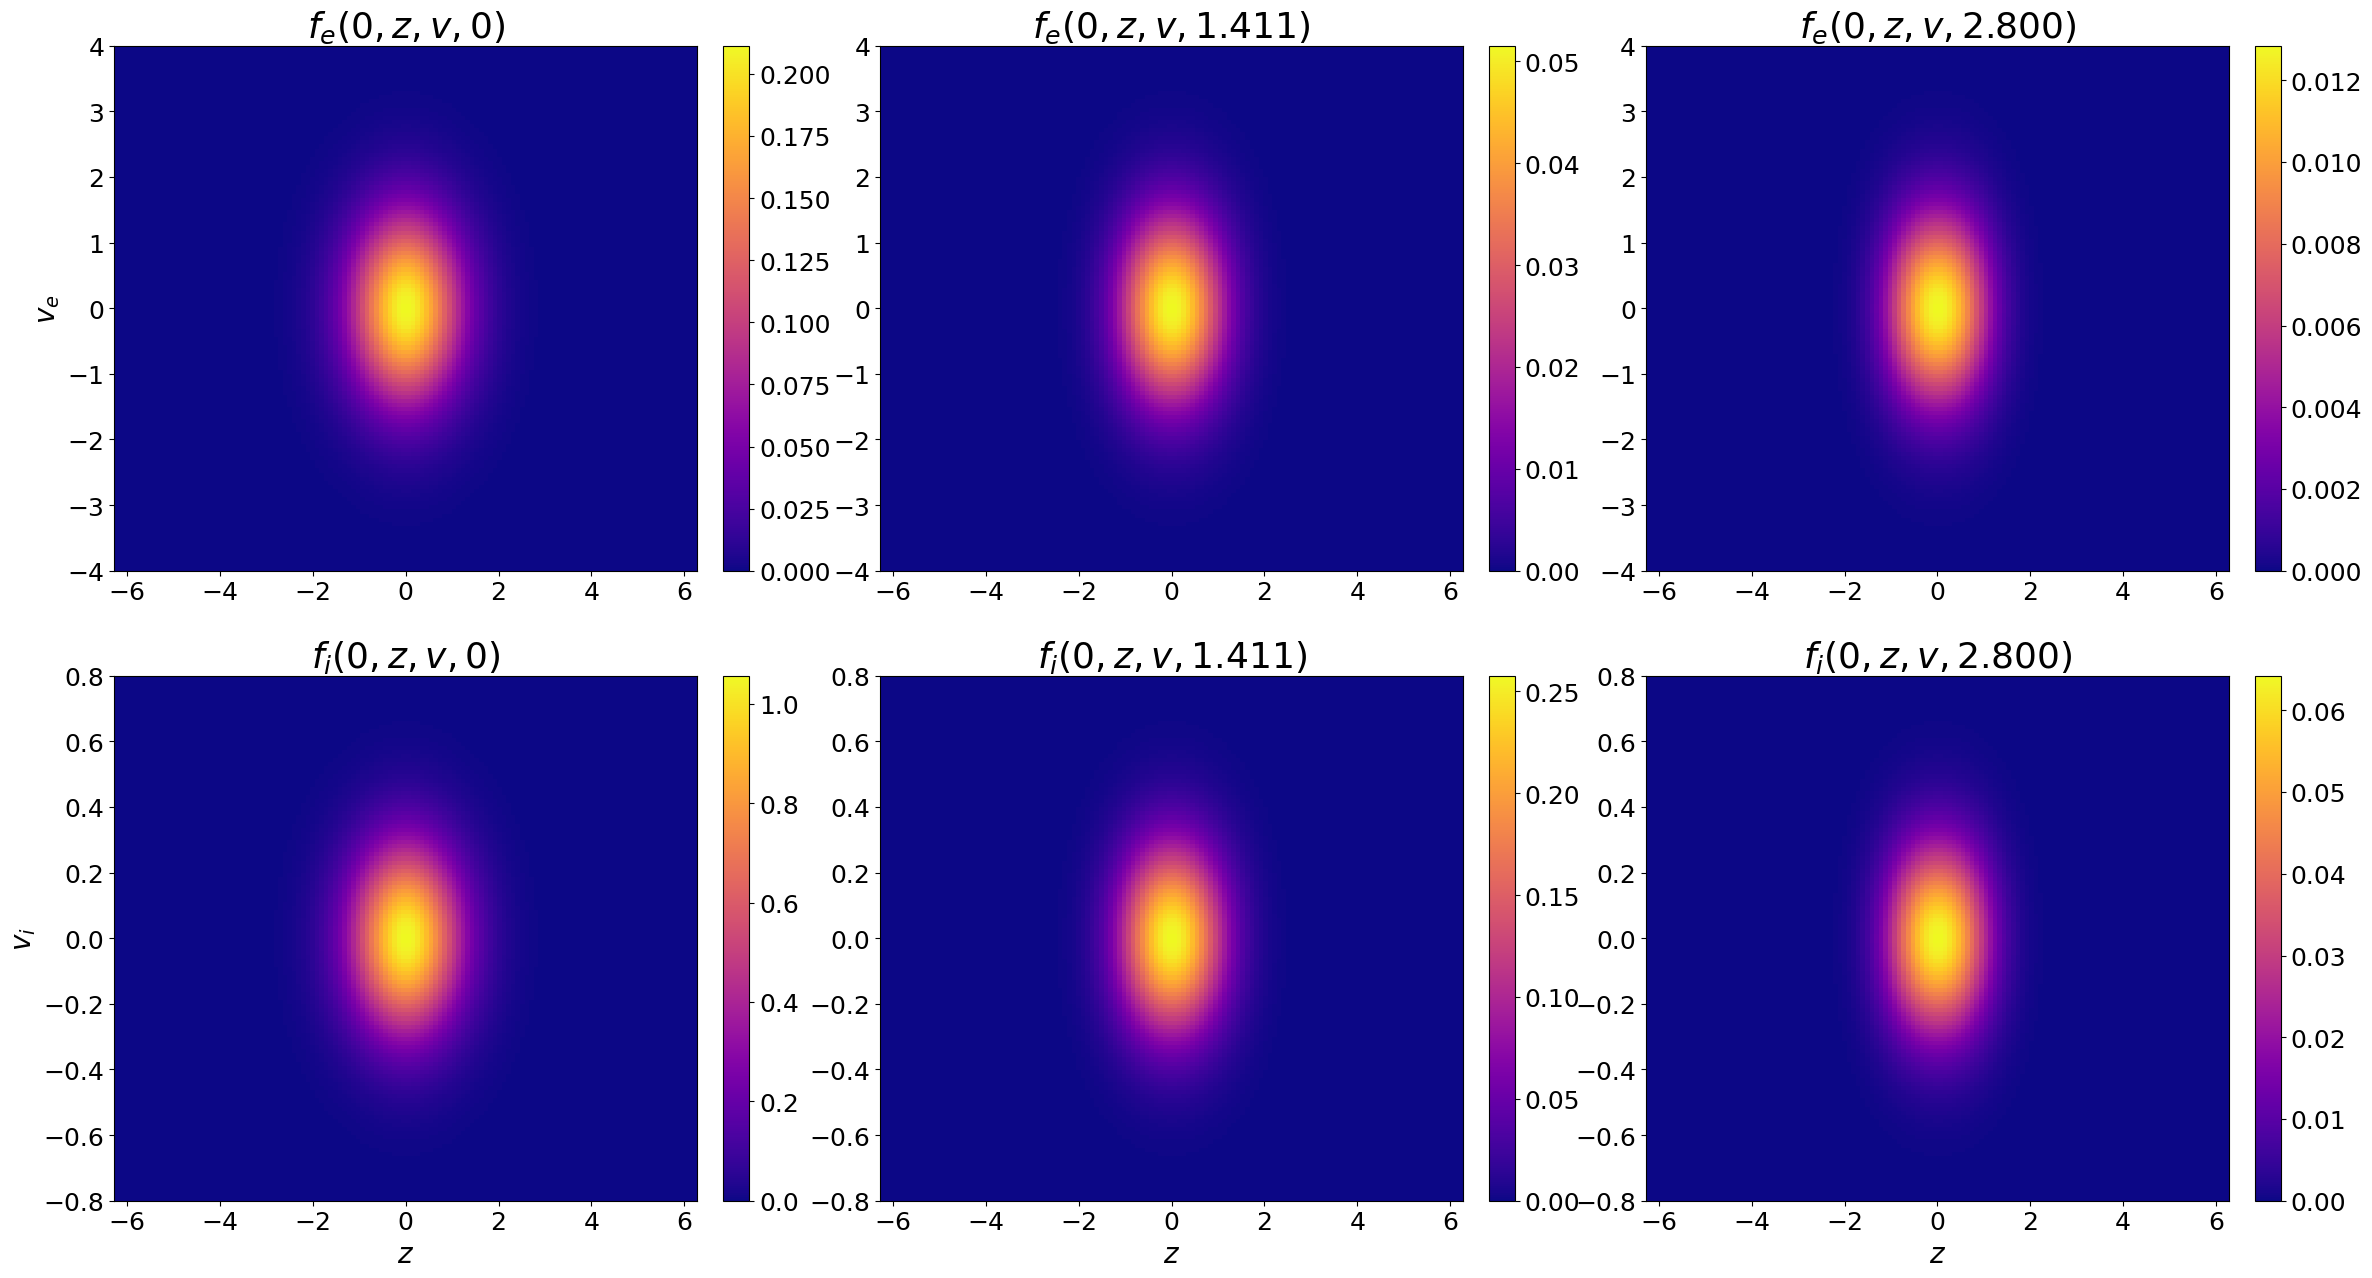

In [6]:
plot_initial_distribution_multi(f_iv_e_init, f_iv_i_init, mesh)

In [7]:
solver = VlasovPoissonSolverFull(mesh=mesh, dt=dt)

#### Optimization step

Skip if there is an already loaded $|\mathbf{B}|$ field to use.

In [8]:
# Optimizer and opt_state
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=1e-3)
)
opt_state = optimizer.init(eqx.filter(b_model, eqx.is_inexact_array))

def step(model, state):
    return step_multi(
        model=model,
        opt_state=state,
        optimizer=optimizer,
        sigma_z=sigma_z, 
        solver=solver,
        t_final=t_final,
        m_i=m_i,
        mesh=mesh
    )

# Run optimization
epochs = 100
pbar = tqdm(range(epochs), desc="Optimizing B-Field MLP")
for i in pbar:
    b_model, opt_state, loss_val = step(b_model, opt_state)

    # Update the progress bar postfix with the latest loss
    # You can add more metrics here if you track them!
    pbar.set_postfix({"Loss": f"{loss_val:.4e}"})

# The path where you want to save it
save_path = "trained_bfields/optimized_b_field_model_multi.eqx"
# Serialize the leaves (arrays) of your PyTree
eqx.tree_serialise_leaves(save_path, b_model)
print(f"Model saved successfully to: {save_path}")

Optimizing B-Field MLP:   0%|          | 0/100 [00:00<?, ?it/s]

Optimizing B-Field MLP: 100%|██████████| 100/100 [58:42<00:00, 35.23s/it, Loss=-1.9097e+00]

Model saved successfully to: trained_bfields/optimized_b_field_model_multi.eqx


#### Loading optimal $|\mathbf{B}|$ profile

In [9]:
load_trained_path = "trained_bfields/optimized_b_field_model_multi.eqx"
B_fn_grid_opt, dB_fn_grid_opt, B_eval_opt, dB_eval_opt, g_eval_opt = load_b_trained(0, mesh.zs, load_trained_path)

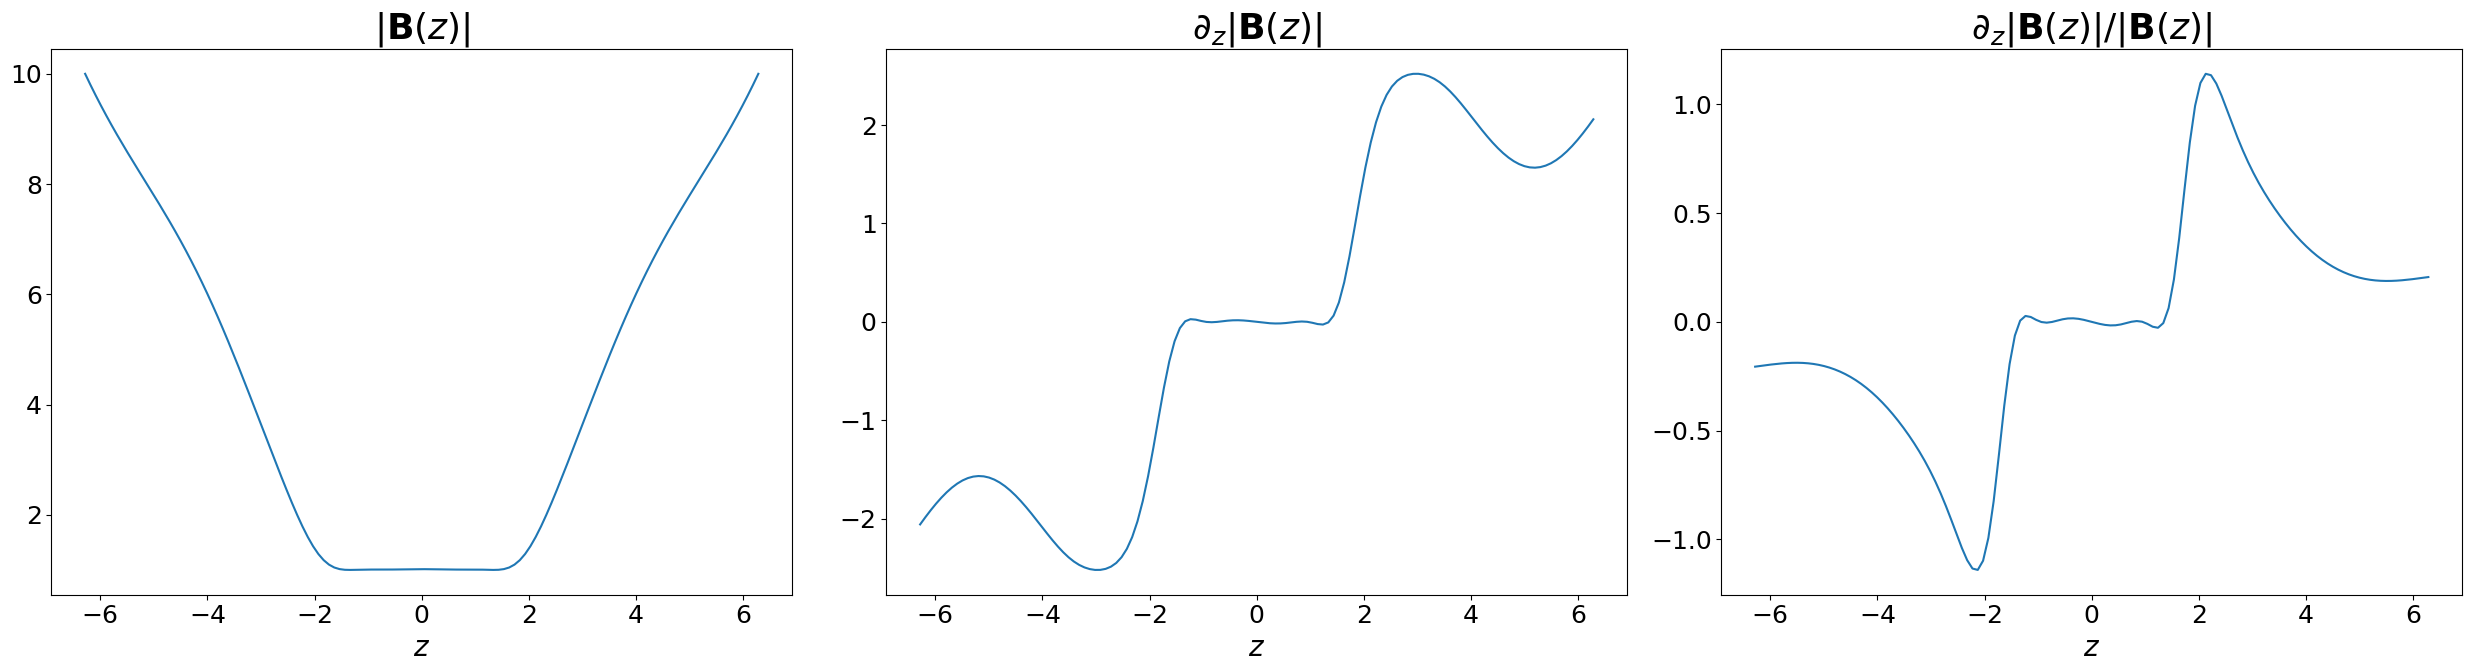

In [10]:
plot_magnetic_fields(B_eval_opt, dB_eval_opt, g_eval_opt, mesh.zs)

We load and plot the initial $f_e$ and $f_i$ given our optimal magnetic profile.

In [11]:
f_iv_e_opt, f_iv_i_opt = get_initial_distribution_multi(B_fn_grid_opt, sigma_z, mesh, m_i)

print("\\int\\rho_e dz: ", jnp.trapezoid(jnp.trapezoid(jnp.trapezoid(f_iv_e_opt, x=mesh.mus, axis=2), x=mesh.vs_e, axis=1), x=mesh.zs, axis=0))
print("\\int\\rho_i dz: ", jnp.trapezoid(jnp.trapezoid(jnp.trapezoid(f_iv_i_opt, x=mesh.mus, axis=2), x=mesh.vs_i, axis=1), x=mesh.zs, axis=0))

\int\rho_e dz:  1.0
\int\rho_i dz:  1.0


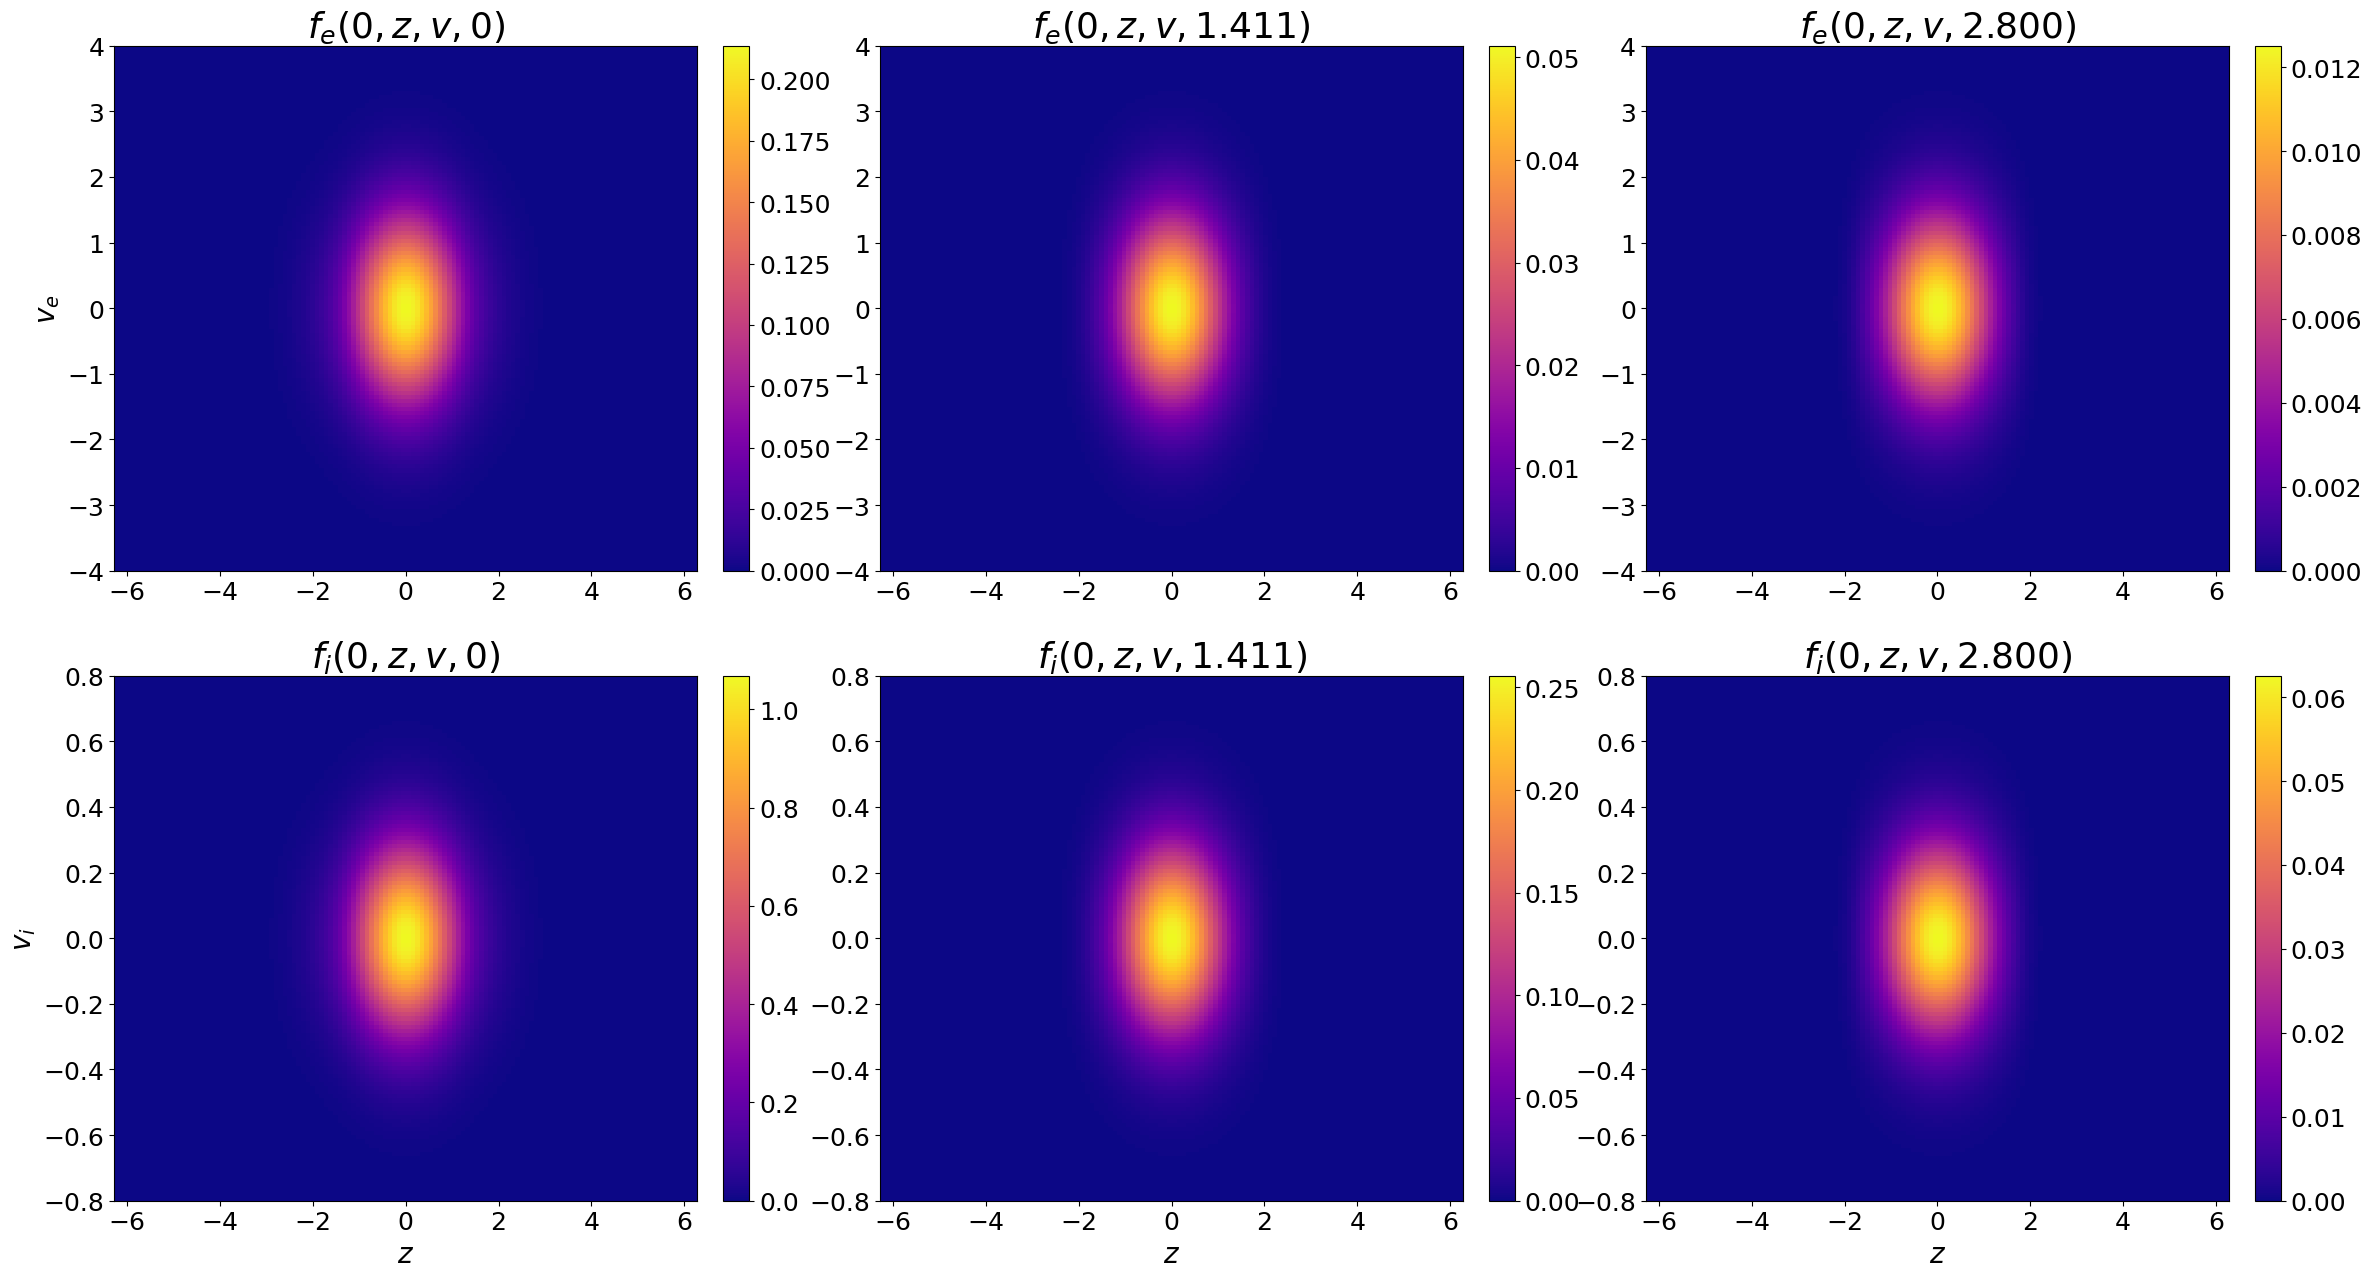

In [12]:
plot_initial_distribution_multi(f_iv_e_opt, f_iv_i_opt, mesh)

In [13]:
# JIT-compiled forward solvers
solver_jit = eqx.filter_jit(solver.run_forward_jax_scan)

In [14]:
(f_e_array_opt, f_i_array_opt), E_total_array_opt, ee_array_opt, rho_e_array_opt, rho_i_array_opt = solver_jit(f_iv_e_opt, f_iv_i_opt, B_eval_opt,
                                                                                                               dB_eval_opt, g_eval_opt, t_final)
(f_e_array_init, f_i_array_init), E_total_array_init, ee_array_init, rho_e_array_init, rho_i_array_init = solver_jit(f_iv_e_init, f_iv_i_init, B_eval_init,
                                                                                                               dB_eval_init, g_eval_init, t_final)

We plot the results: first using the initial guess configuration for $|\mathbf{B}|$ and then using the optimal one.

In [15]:
norm_il, norm_ic, norm_ir, norm_el, norm_ec, norm_er = normalize_final_multi(f_e_array_opt,
                                                                             f_e_array_init, 
                                                                             f_i_array_opt, 
                                                                             f_i_array_init, 
                                                                             mesh)

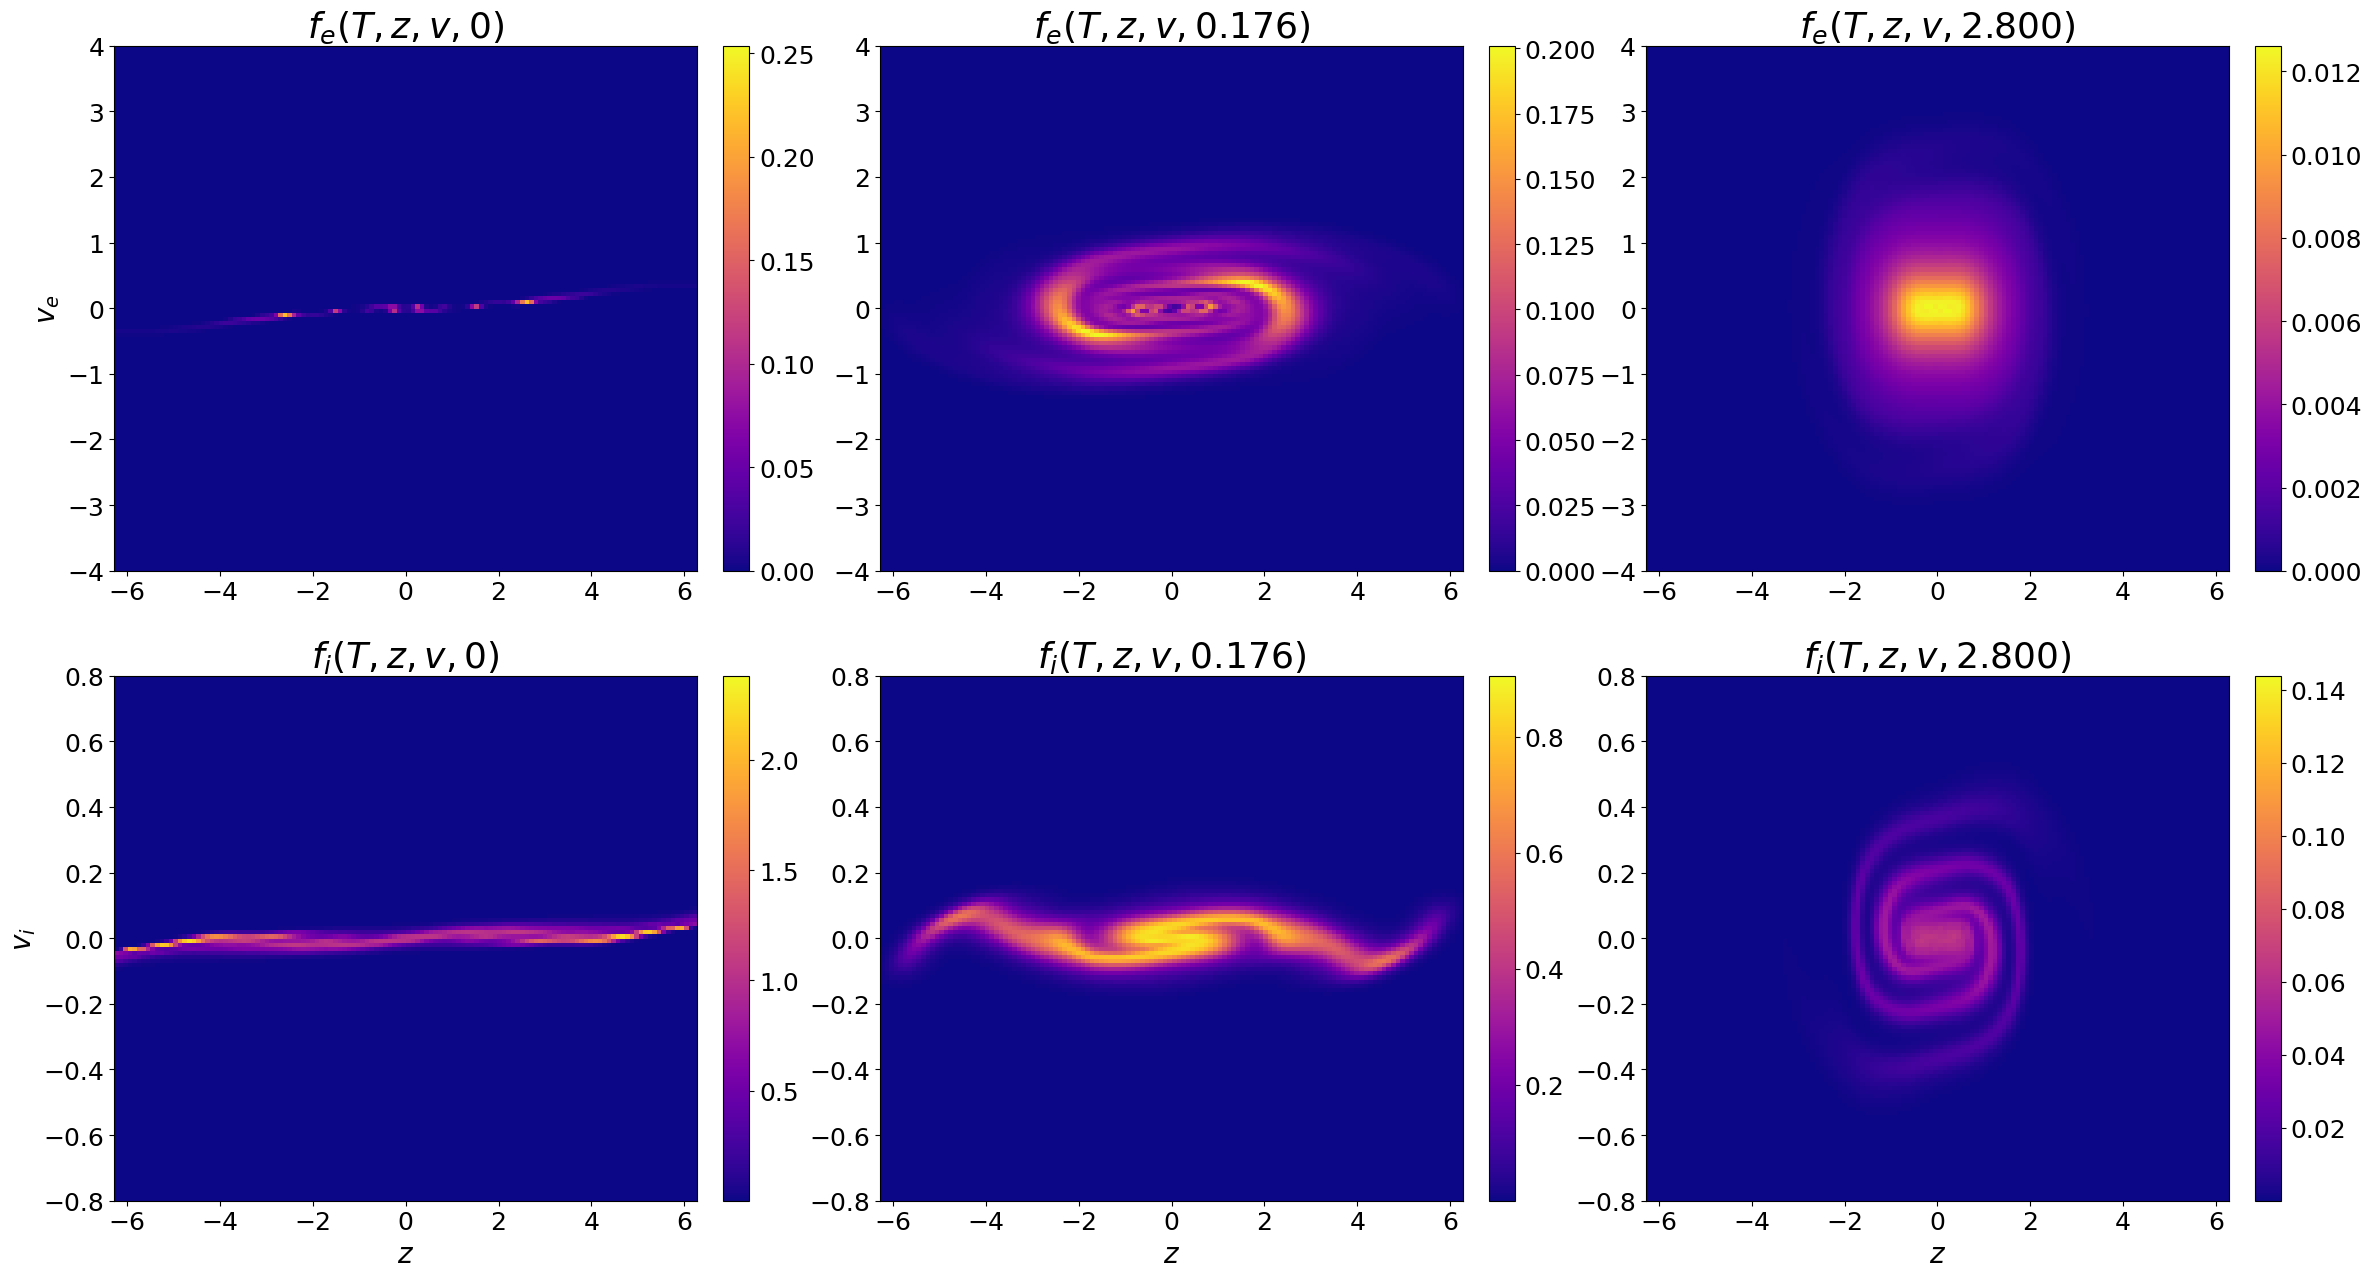

In [16]:
plot_final_distribution_multi(f_e_array_init, f_i_array_init,
                                   norm_il, norm_ic, norm_ir, norm_el, norm_ec, norm_er, mesh)

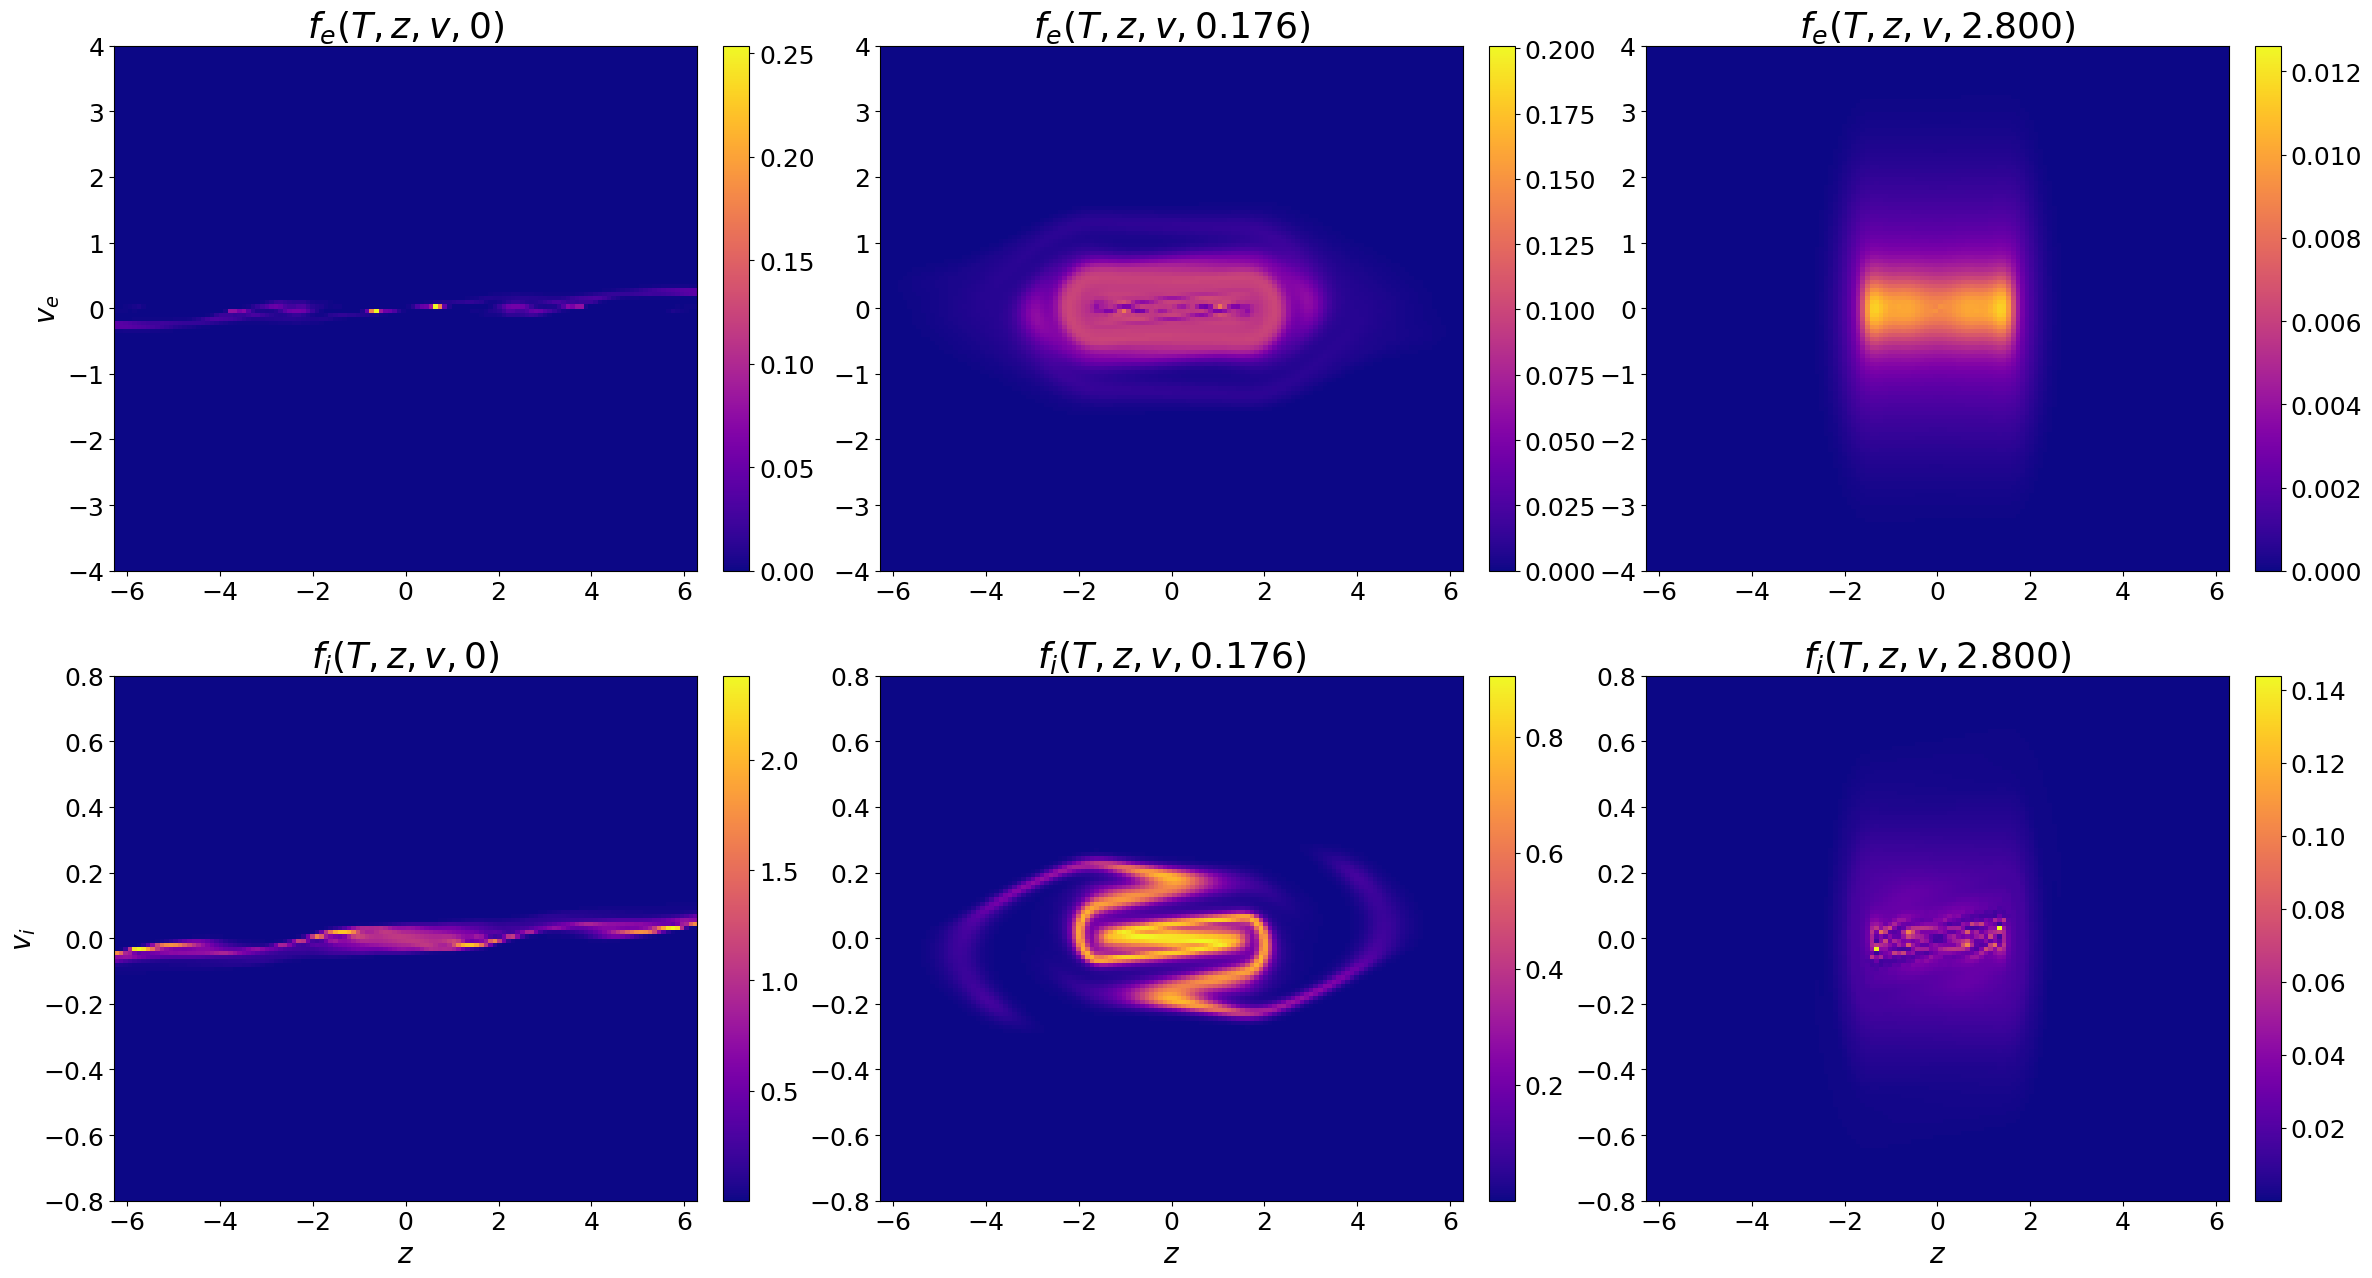

In [17]:
plot_final_distribution_multi(f_e_array_opt, f_i_array_opt,
                                   norm_il, norm_ic, norm_ir, norm_el, norm_ec, norm_er, mesh)

We plot the electrical energy $\mathcal{E}(t)$ defined as

$$
\mathcal{E}(t) = \frac{1}{2}\int_{-L_z}^{L_z}E(t,z)^{2}\,\mathrm{d}z\,. 
$$

for both configurations (top: initial; bottom: optimal).

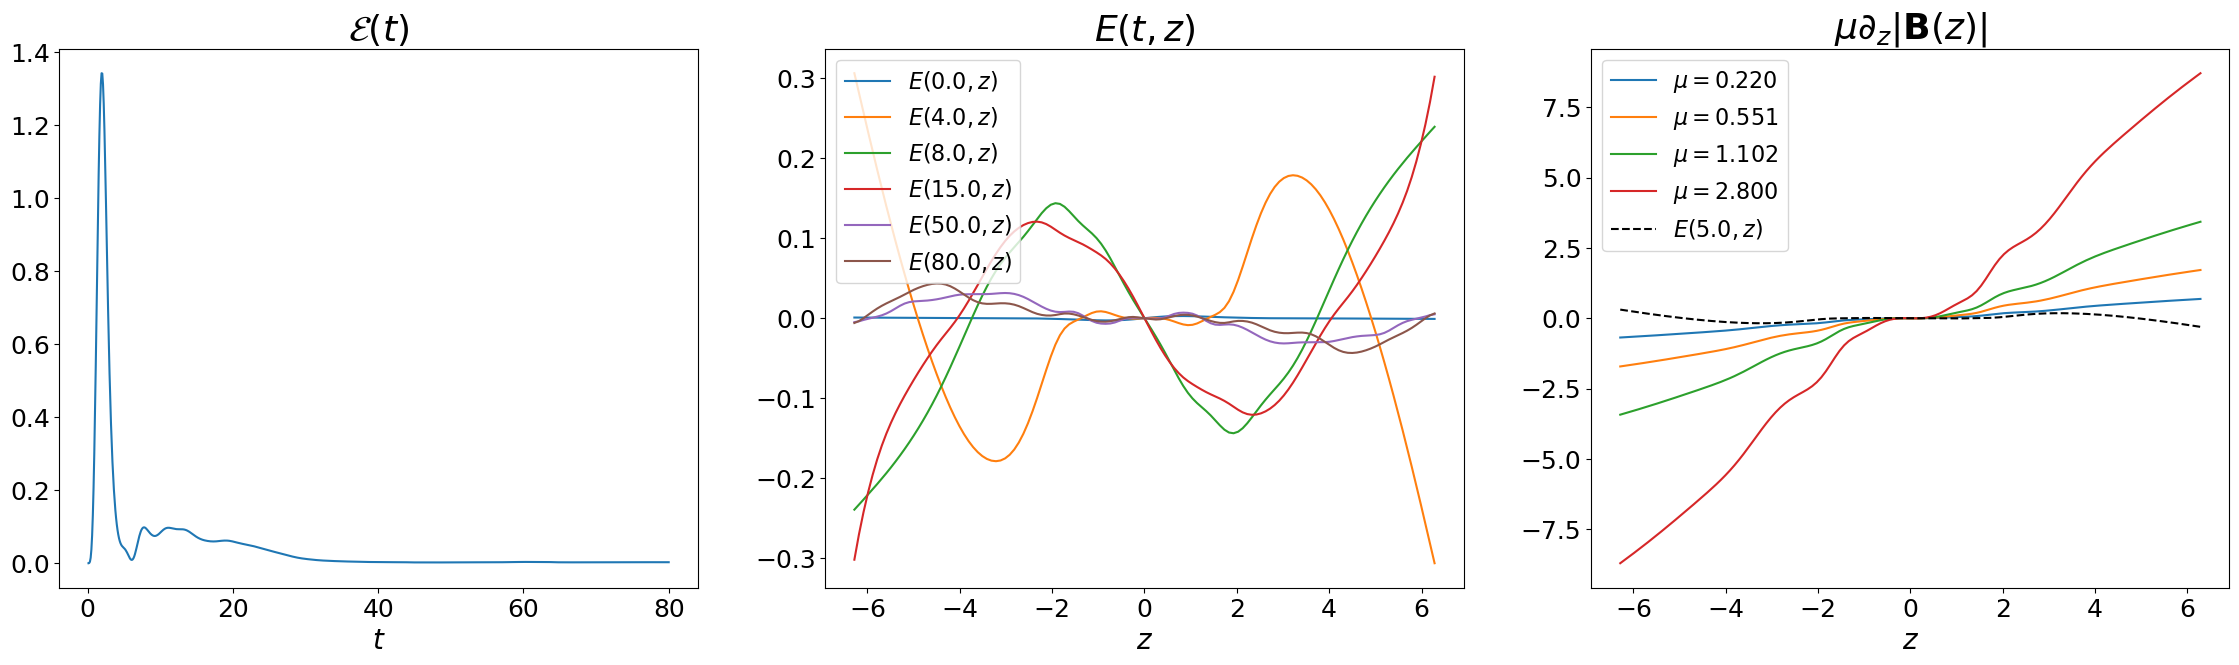

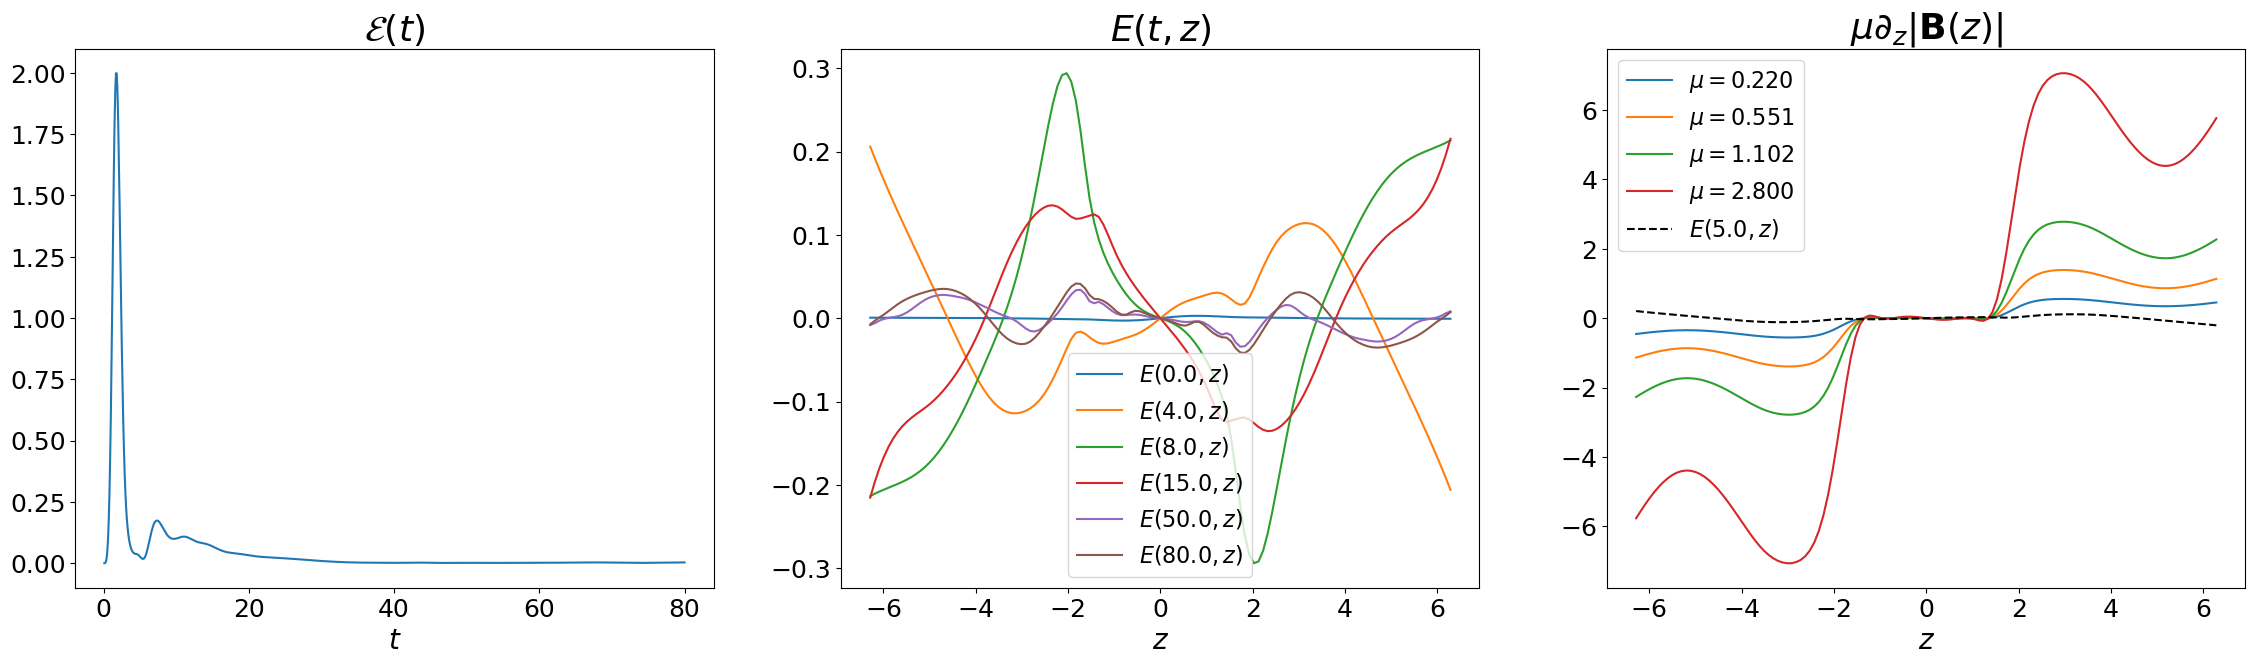

In [18]:
plot_energies_multi(t_values, ee_array_init, E_total_array_init, dB_eval_init, mesh)
plot_energies_multi(t_values, ee_array_opt, E_total_array_opt, dB_eval_opt, mesh)

We plot two density quantities for $s\in\{e,i\}$: the three-dimensional density, which is given by
$$
\rho_s(t,z)
=
2\pi |\mathbf{B}(z)|
\iint
f_s(t,z,v,\mu)
\,\mathrm{d}v\,\mathrm{d}\mu\,,
$$
and the effective longitudinal density, which is given by
$$
\rho_s^{1D}(t,z)
=
\iint
f_s(t,z,v,\mu)
\,\mathrm{d}v\,\mathrm{d}\mu\,.
$$

In addition, to see the level of confinement in time we plot

$$\int_{-L_z}^{L_z}\rho_s^{1D}(t,z)\,\mathrm{d}z\,.$$

For every first is initial guess and then is the optimal configuration for $|\mathbf{B}|$.

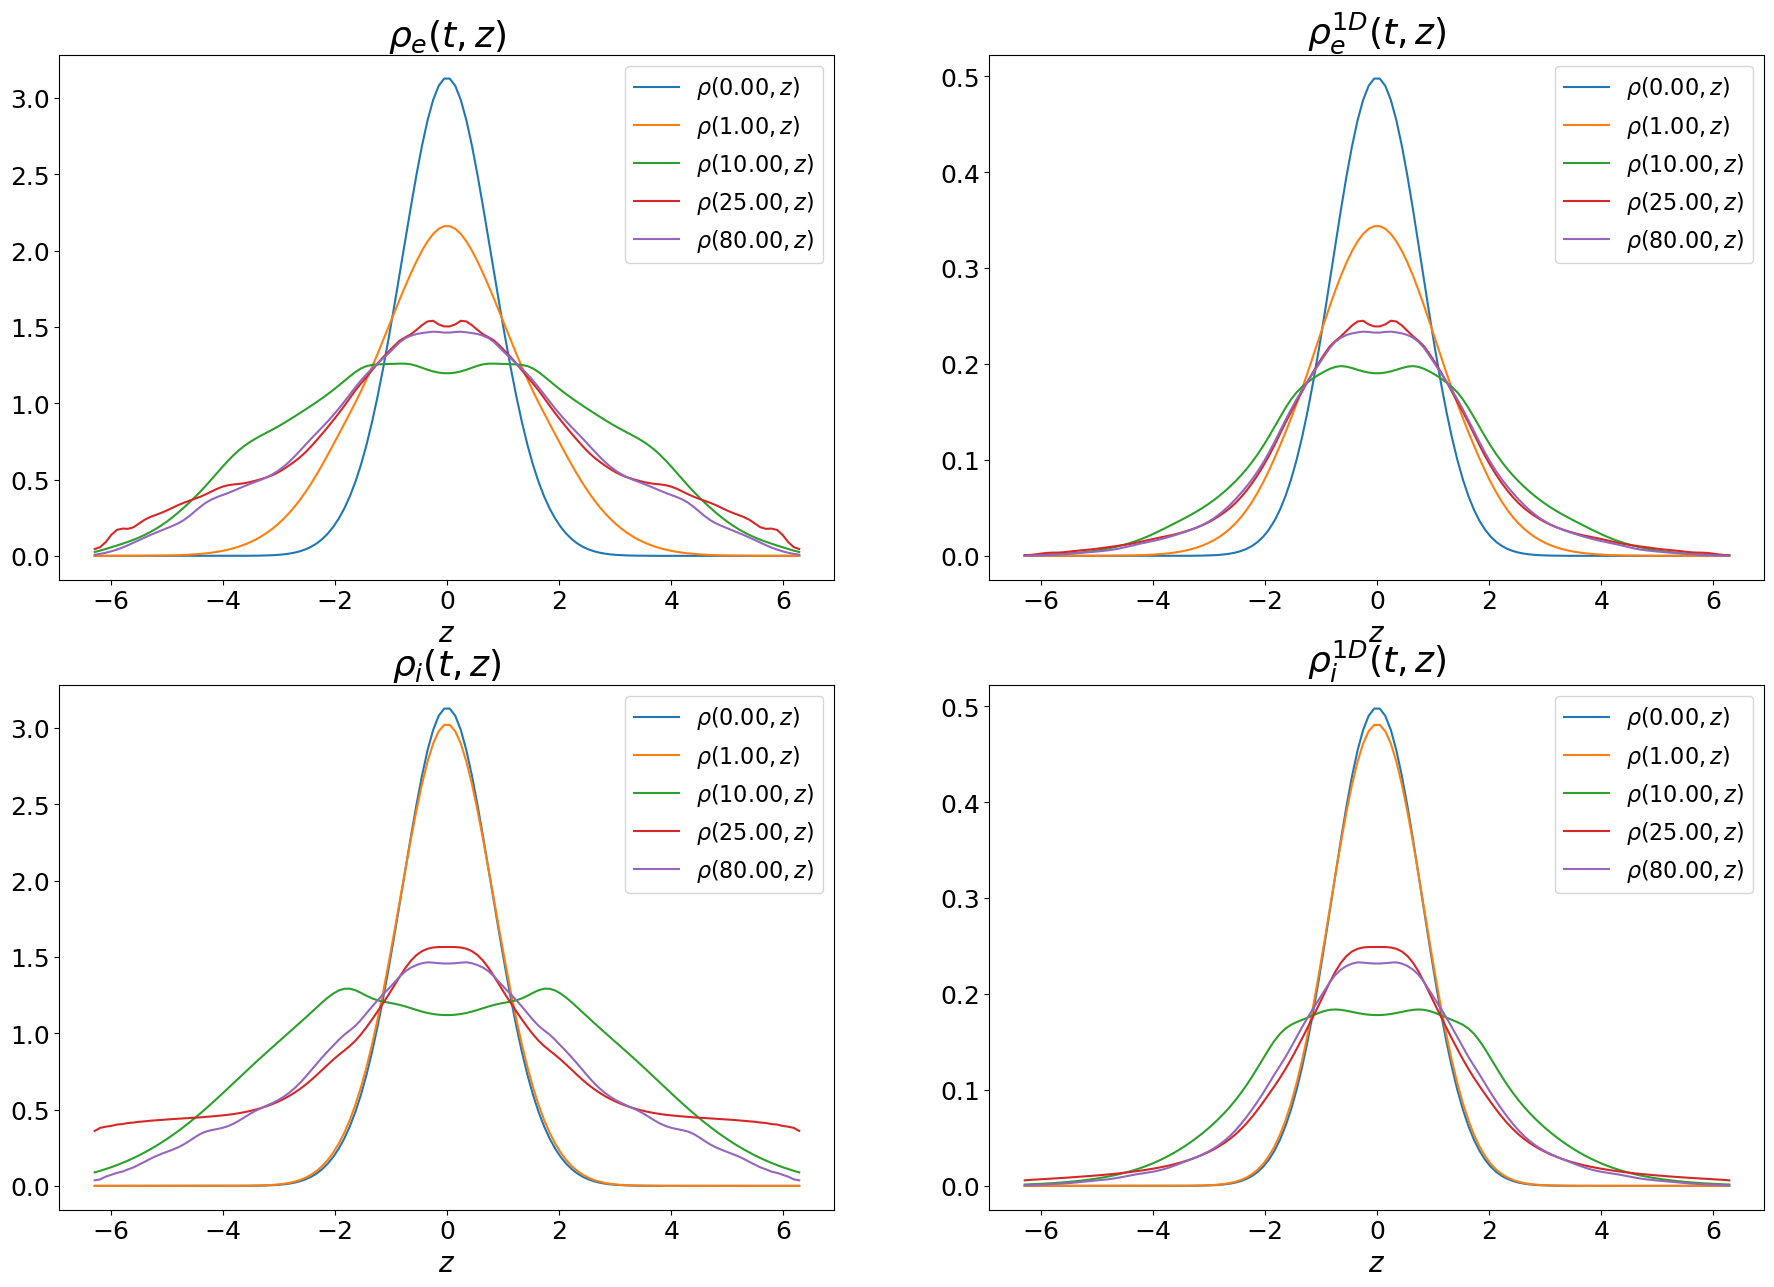

In [19]:
plot_rhos_multi(rho_e_array_init, rho_i_array_init, B_eval_init, t_values, mesh)

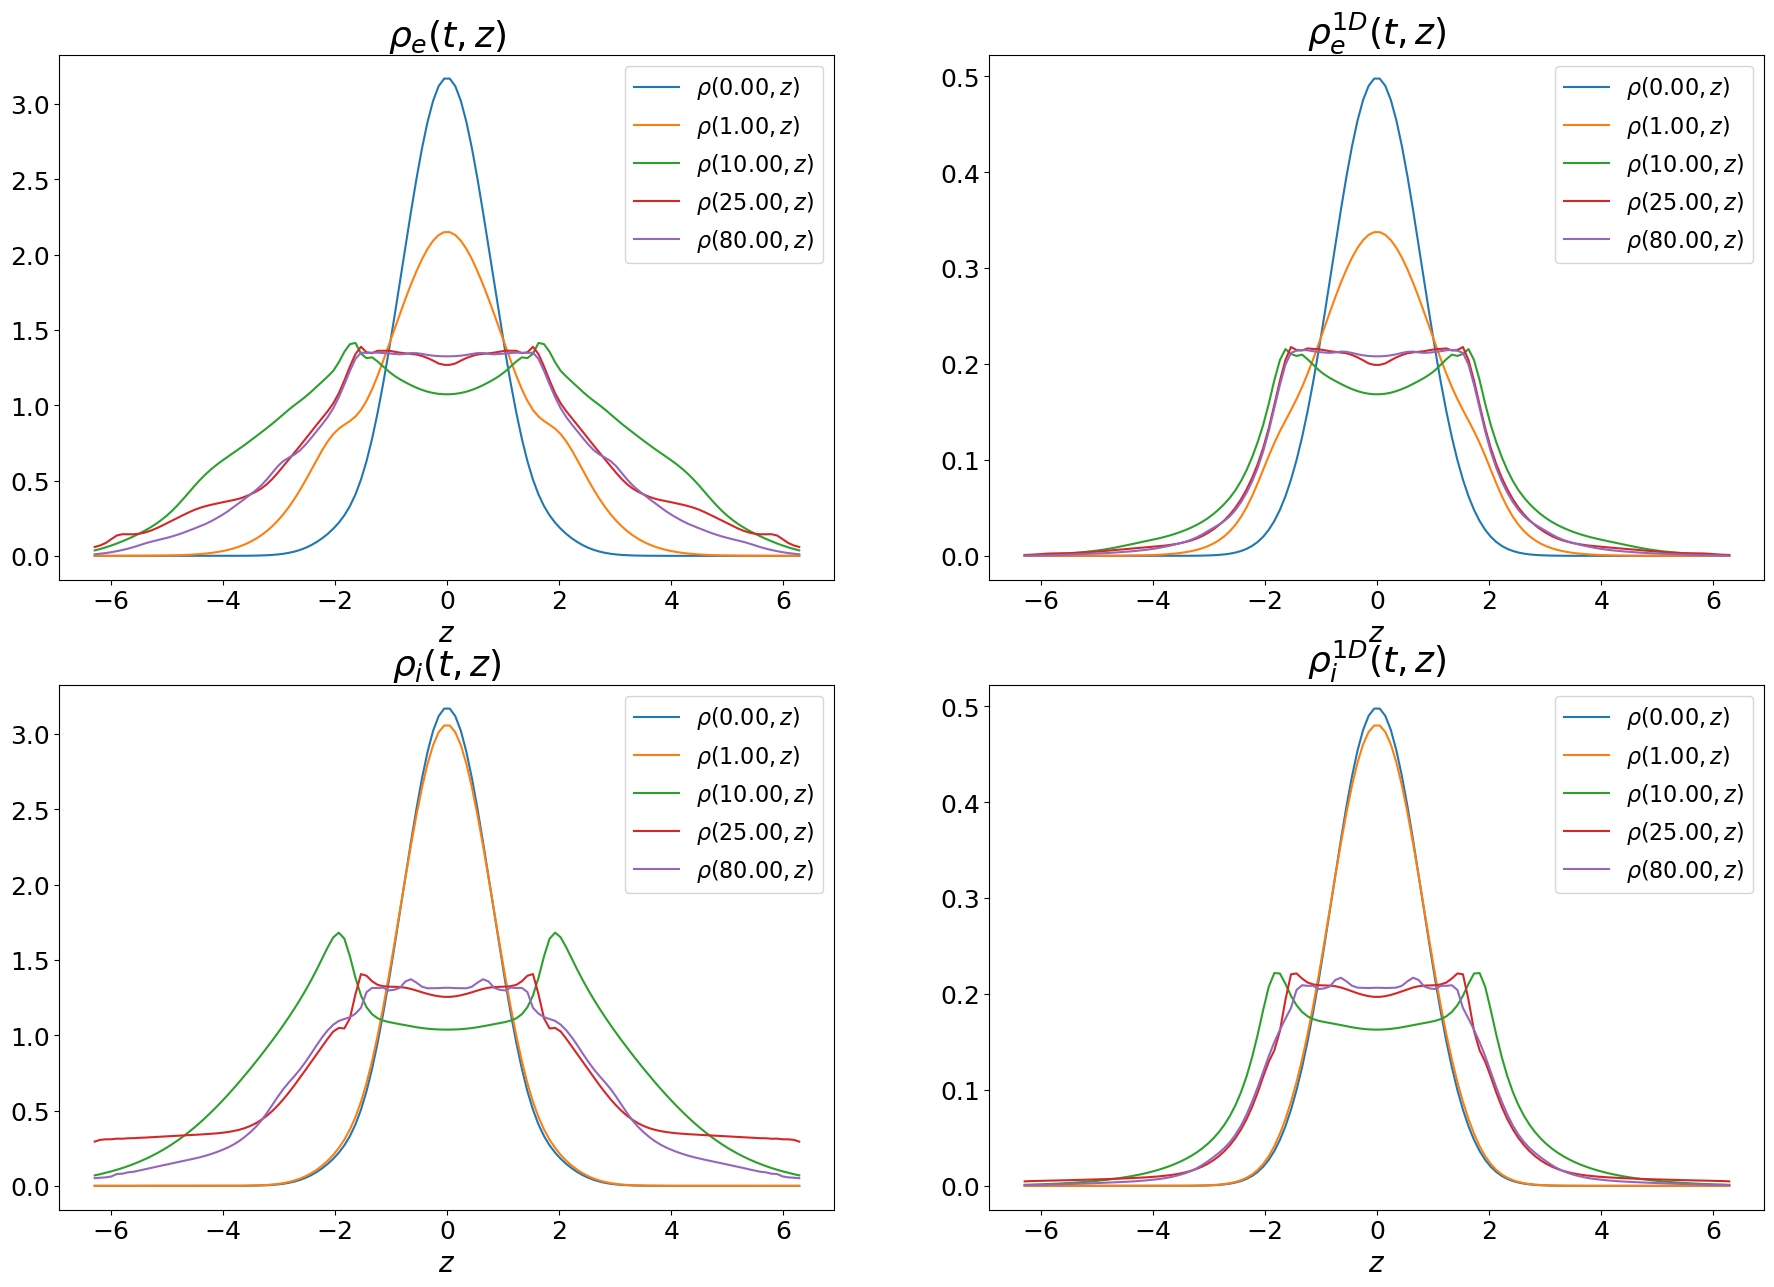

In [20]:
plot_rhos_multi(rho_e_array_opt, rho_i_array_opt, B_eval_opt, t_values, mesh)

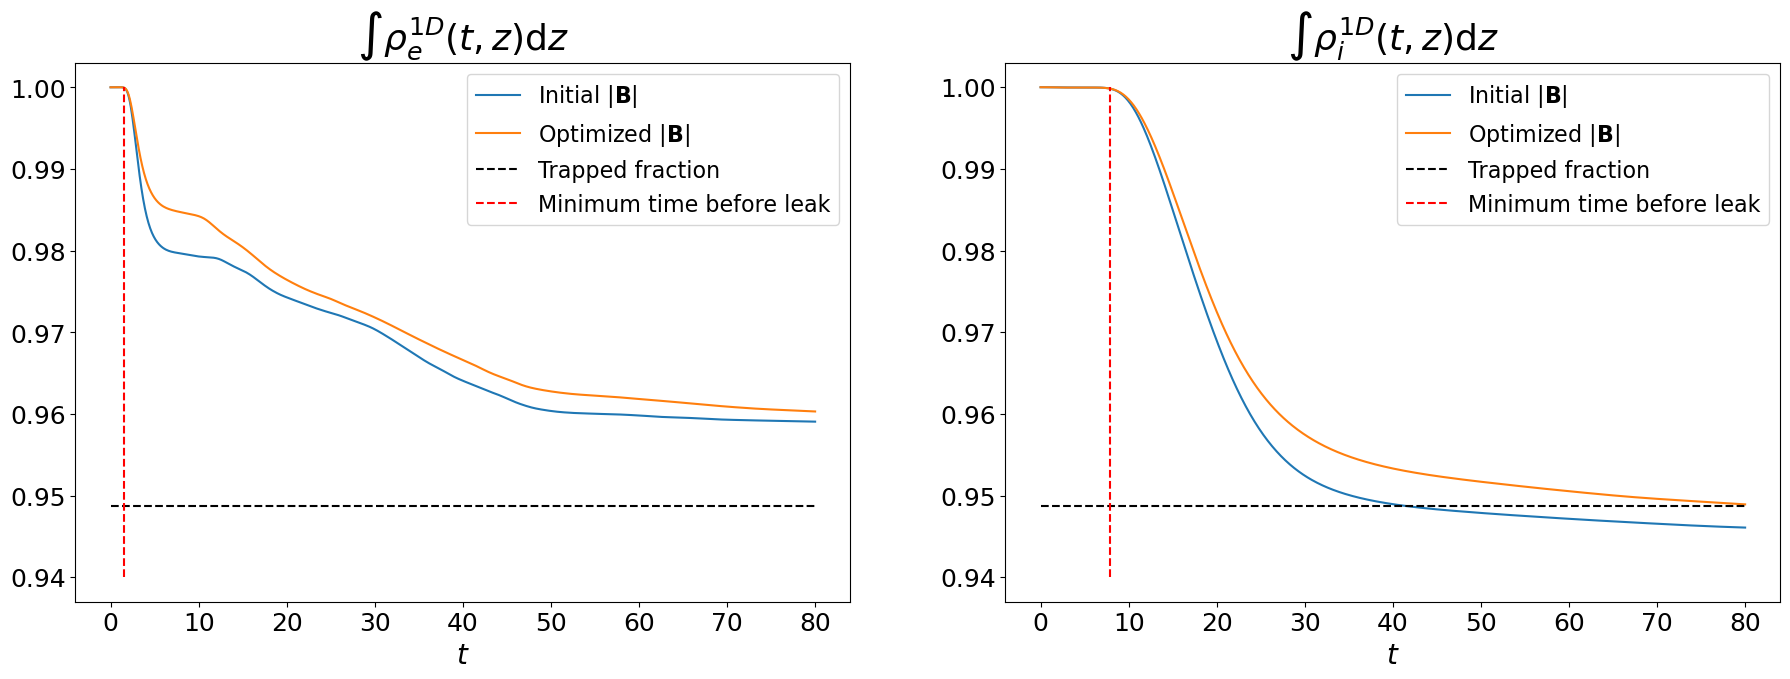

In [21]:
plot_int_rho_multi(rho_e_array_init, rho_e_array_opt, rho_i_array_init, rho_i_array_opt, prop_trapped, LZ, LV, m_i, t_values, mesh)

#### Summary of results

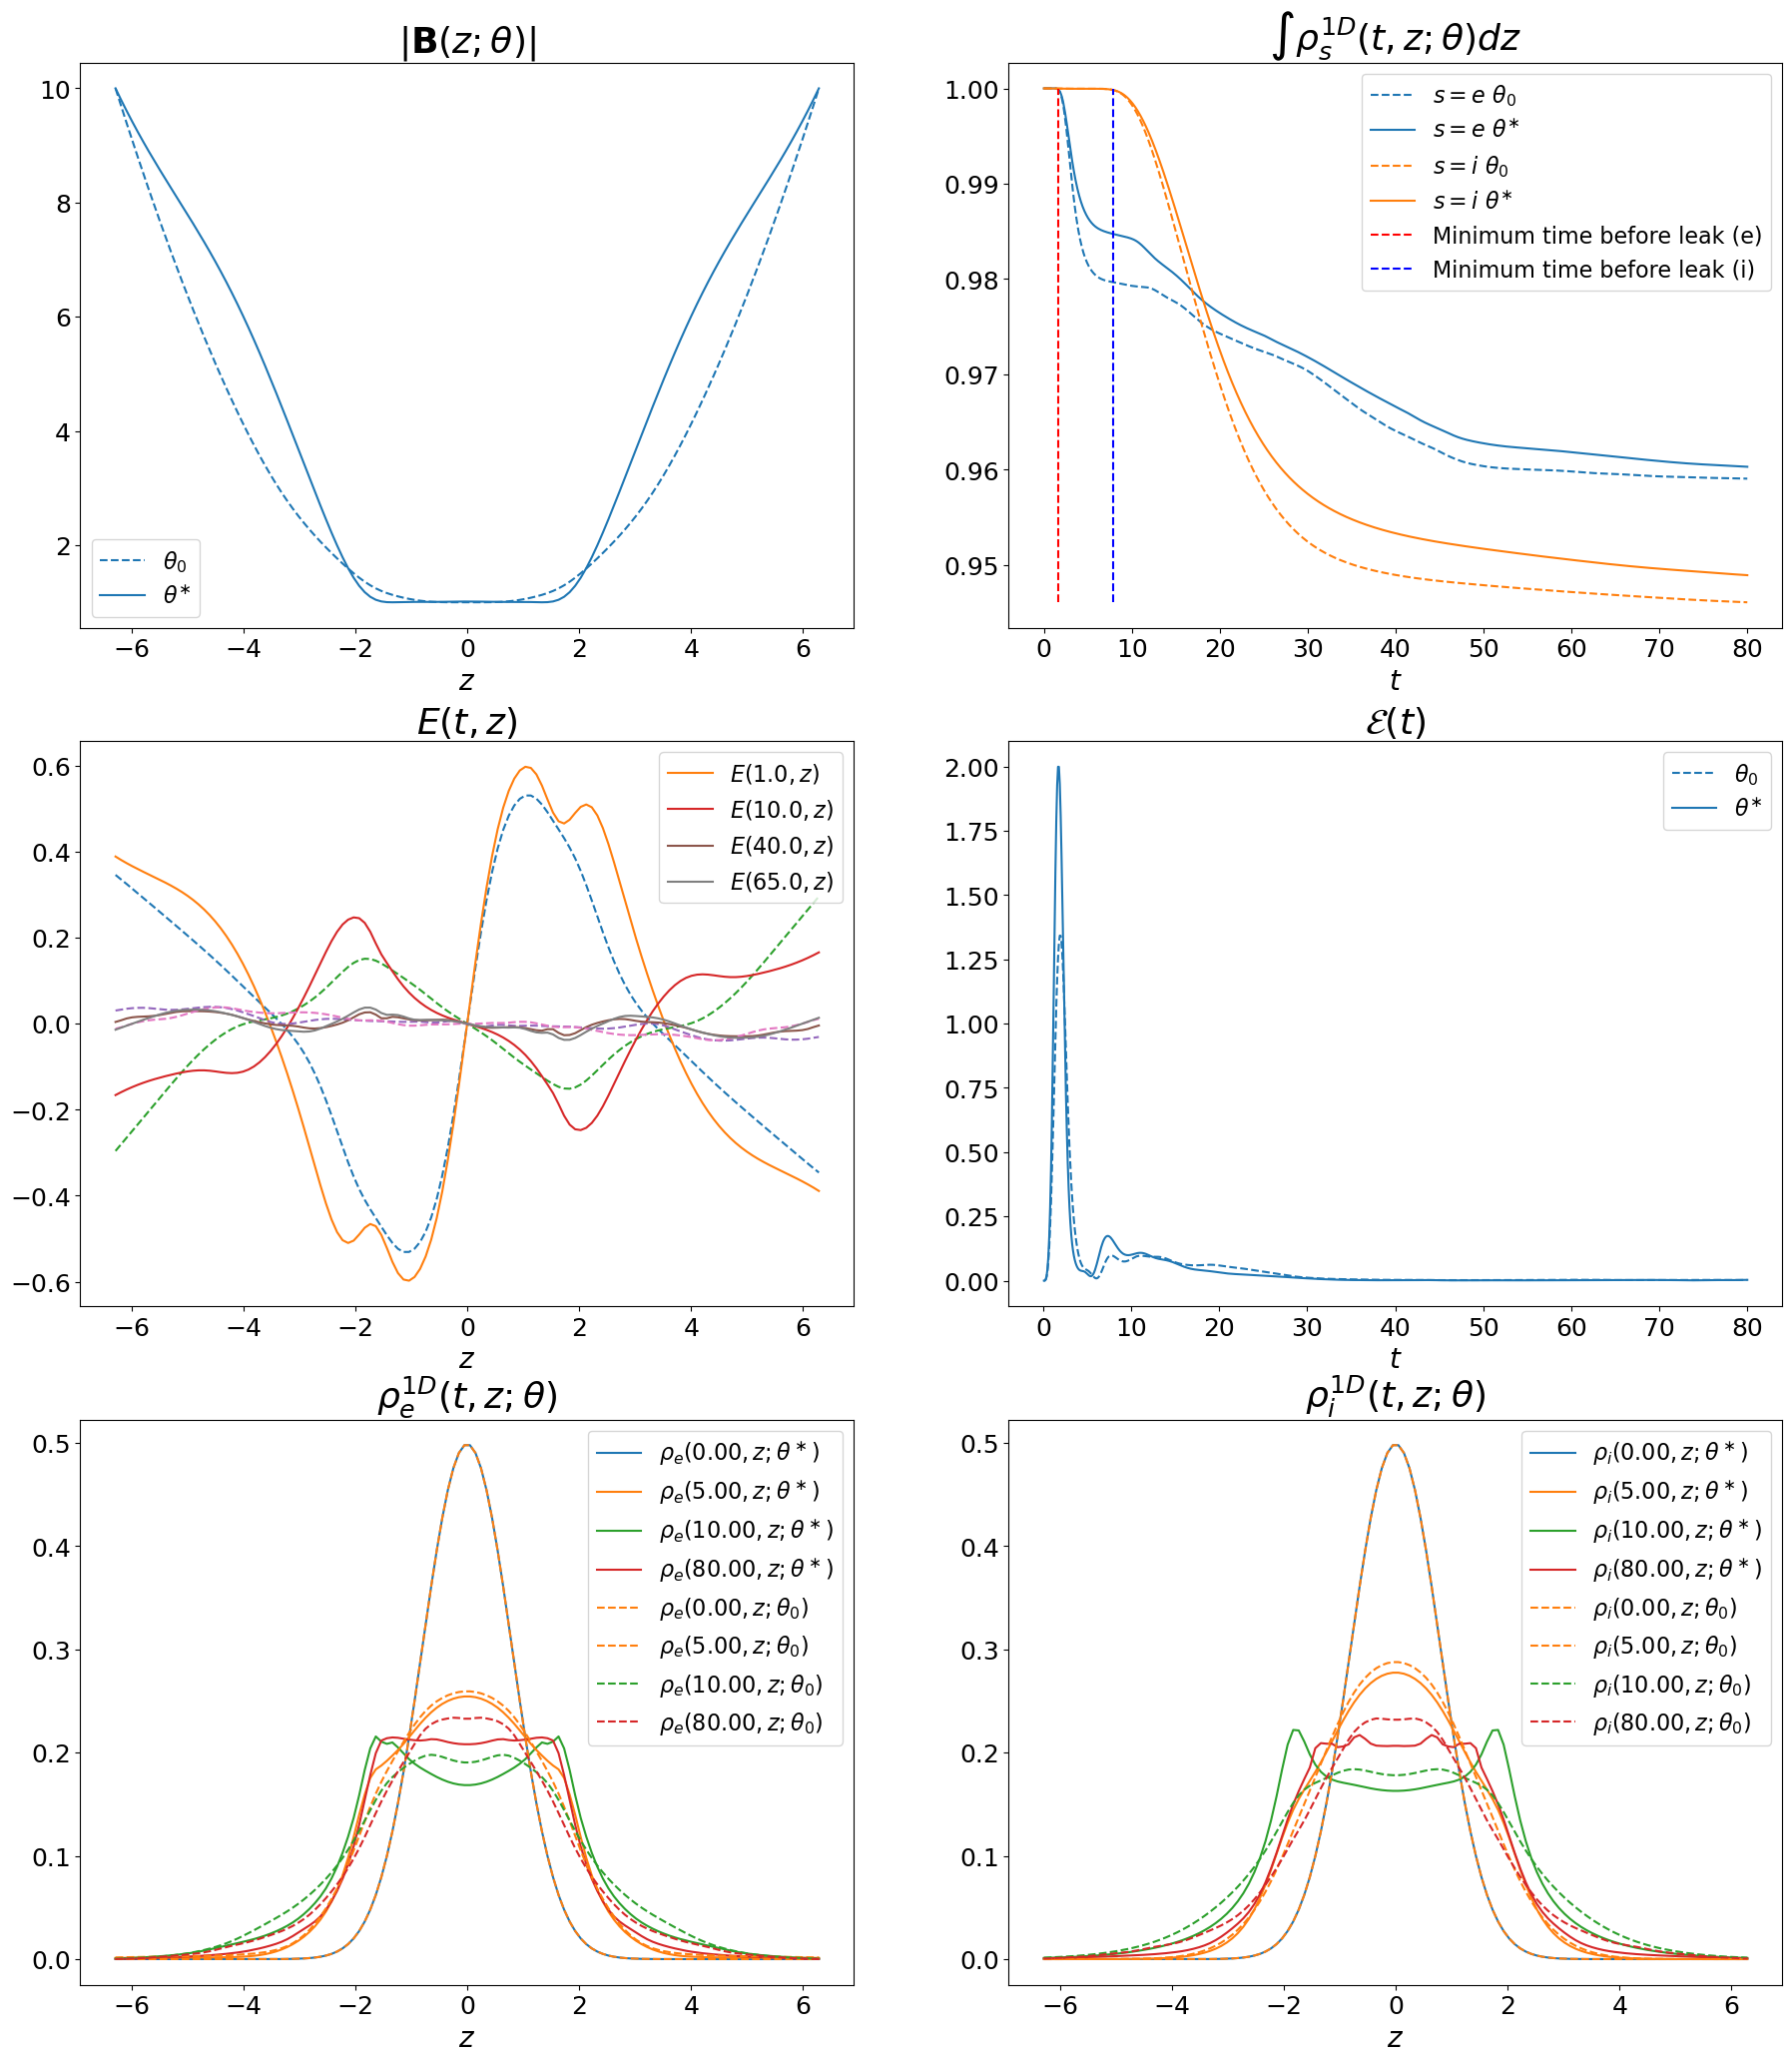

In [22]:
plot_summray_opt_multi(B_eval_init, B_eval_opt, t_values, rho_e_array_init, rho_e_array_opt, rho_i_array_init,
                       rho_i_array_opt, E_total_array_init, E_total_array_opt, ee_array_init, ee_array_opt, m_i, mesh, LZ, LV)